# Paper figures

Fiducial inference setup: $n_\mathrm{train}=10\,000$ cosmologies, $b_x=32$ bias sets per cosmo, noisy (`biasnoisenest`), `_best-rand30` checkpoints.

Fiducial statistics: $P_{gg}$; $P_{gg}+P_{gm}$; $P_{gg}+B$; $P_{gg}+B+P_{gm}$.

Results plots use **un-reparameterized** parameters ($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$) via `unreparameterize=True` in `plotter`.

In [1]:
import sys
from datetime import date
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_model

%load_ext autoreload
%autoreload 2

In [2]:
# --- Fiducial config ---
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "_kpgm0.25", "_kb0.25", "_kb0.25_kpgm0.25"]
# pk, pk+pgm, pk+bispec, pk+bispec+pgm
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168"]

TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

TAG_PARAMS_TEST_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_TEST_COV = "_biasnoisecoverage_p9_n1000"
TAG_NOISE_TEST_COV = "_noise_unit_coverage_p5_n1000"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
PARAM_NAMES_ZOOM = list(param_names_key)
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_mid = extents.copy()
extents_mid["b1"] = [-0.4, 1.4]
extents_narrow = extents.copy()
extents_narrow["b1"] = [0.2, 0.7]
extents_contours = extents.copy()
extents_contours["b1"] = [0.0, 1.0]

FIGSIZE_CORNER = (5, 5)
FIGSIZE_ALL_PARAMS = (9, 9)
FONTSIZE_LEGEND = 12
LOC_LEGEND = (1.02, 0.98)
KMAX_LOOSE = 0.4  # pk-only implicit cut; used in scale-sweep section only
ANOISE_OPTION = "Anmult"

dir_sbi = paths.DIR_RESULTS / "results_sbi"
n_cosmo_max_stats = 100  # subsample for statistics range plots

FIG_DIR = REPO_ROOT / "figures" / "2026-06-25_paper_figures"
OVERWRITE_FIGURES = True
FIG_EXT = "png"


def save_figure(fig, name, ext=FIG_EXT):
    """Save figure to FIG_DIR; skip if file exists and OVERWRITE_FIGURES is False."""
    path = FIG_DIR / f"{name}.{ext}"
    if path.exists() and not OVERWRITE_FIGURES:
        print(f"Skipping save (exists, overwrite=False): {path}")
        return
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")


def save_current_figure(name, ext=FIG_EXT):
    save_figure(plt.gcf(), name, ext=ext)



def setup_fiducial_inference():
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=STATISTICS_ARR_FID,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=TAGS_MASK_FID,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    labels = [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID]
    return tags_inf, labels, list(COLORS_FID)


def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"


def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]


def setup_fixed_mean_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary


def setup_coverage_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_COV,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_COV,
        tag_datagen_test="",
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    return tags_inf, labels, colors, tags_test, keep, cosmo_vary, bias_vary, param_vary


def setup_shame_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' + m for s, m in zip(STATISTICS_ARR_FID, TAGS_MASK_FID)]
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=TAG_MOCK_SHAME,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME)
    theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, param_vary, theta_obs_full[idxs_zoom]


def plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep, theta_show, *,
    extents=None, add_truth=True, save_name=None,
):
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print("No samples on disk for fiducial contours")
        for i, k in enumerate(keep):
            if not k:
                print(f"  missing: {sample_fn(tags_inf[i], tags_test[i])}")
        return
    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=None,
        extents=extents or extents_mid,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
        add_truth=add_truth,
    )
    if save_name is not None:
        save_current_figure(save_name)


def stats_summary(arr):
    return (
        np.nanmean(arr, axis=0),
        np.nanpercentile(arr, 5, axis=0),
        np.nanpercentile(arr, 16, axis=0),
        np.nanpercentile(arr, 84, axis=0),
        np.nanpercentile(arr, 95, axis=0),
    )


def plot_stat_band(ax, x, mean, p5, p16, p84, p95, color):
    # Mean first for legend order; zorder keeps the line above the bands.
    ax.plot(x, mean, color=color, label="mean", zorder=3)
    ax.fill_between(x, p16, p84, color=color, alpha=0.35, label="16-84%", zorder=2)
    ax.fill_between(x, p5, p95, color=color, alpha=0.18, label="5-95%", zorder=1)


def filter_finite_coverage_rows(theta_true_arr, theta_pred_arr, covs_pred_arr):
    """Drop coverage rows with NaN predictions (failed / timed-out inference batches)."""
    theta_true_out, theta_pred_out, covs_out = [], [], []
    for i in range(theta_pred_arr.shape[0]):
        ok = np.all(np.isfinite(theta_pred_arr[i]), axis=1)
        if covs_pred_arr.ndim == 4:
            ok &= np.all(np.isfinite(covs_pred_arr[i]).all(axis=2), axis=1)
        theta_true_out.append(theta_true_arr[i][ok])
        theta_pred_out.append(theta_pred_arr[i][ok])
        covs_out.append(covs_pred_arr[i][ok])
    return np.array(theta_true_out), np.array(theta_pred_out), np.stack(covs_out, axis=0)

## 1. mMocks overview

Pipeline: initial conditions → map2map displacement → Eulerian bias fields → biased tracer overdensity field.

*Placeholder — add final figure here.*

In [17]:
# TODO: mMocks pipeline figure (δ_IC → |Ψ| → δ_bias → δ_g)
pass

## 2. Statistics: training-set ranges

Mean and 16–84% bands over the fiducial noisy training set. **Notebook uses $n_\mathrm{cosmo}\leq 100$ subsample for speed; the final paper figure should use the full training set** (set `n_cosmo_max_stats=None` or remove the cap).

Loaded pk with shape (32,)
Loaded pgm with shape (32,)
Loaded bispec with shape (203,)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pks in /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pgms in /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
dir_statistics: /scratch/k

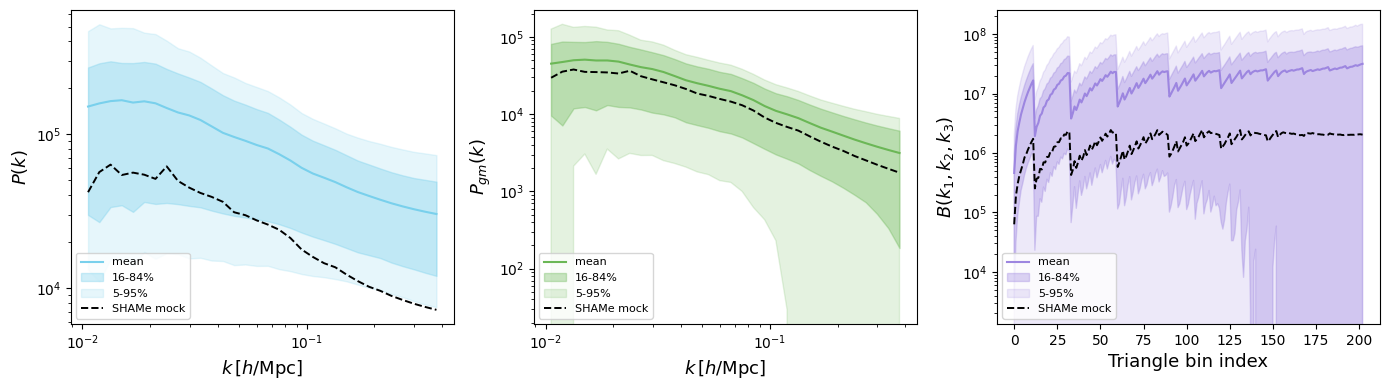

In [18]:
COLOR_STAT = {"pk": COLORS_FID[0], "pgm": COLORS_FID[1], "bispec": COLORS_FID[2]}
SHAME_LINESTYLE = "--"
SHAME_LINEWIDTH = 1.4
LABELSIZE = 13

# SHAMe OOD statistics (dashed black overlay)
k_shame_pk, y_shame_pk, _ = data_loader.load_data_shame("pk", TAG_MOCK_SHAME)
k_shame_pgm, y_shame_pgm, _ = data_loader.load_data_shame("pgm", TAG_MOCK_SHAME)
_, y_shame_bispec, _ = data_loader.load_data_shame("bispec", TAG_MOCK_SHAME)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# P(k)
k_pk, pks, _, _ = data_loader.load_data_muchisimocks(
    "pk", TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN, bx=bx, n_cosmo_max=n_cosmo_max_stats,
)
mean_pk, p5_pk, p16_pk, p84_pk, p95_pk = stats_summary(pks)
plot_stat_band(axes[0], k_pk, mean_pk, p5_pk, p16_pk, p84_pk, p95_pk, COLOR_STAT["pk"])
axes[0].plot(
    k_shame_pk, y_shame_pk, color="black",
    linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label="SHAMe mock", zorder=4,
)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"$k\,[h/\mathrm{Mpc}]$", fontsize=LABELSIZE)
axes[0].set_ylabel(r"$P(k)$", fontsize=LABELSIZE)
axes[0].legend(loc="lower left", fontsize=8)

# P_gm(k)
k_pgm, pgms, _, _ = data_loader.load_data_muchisimocks(
    "pgm", TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN, bx=bx, n_cosmo_max=n_cosmo_max_stats,
)
mean_pgm, p5_pgm, p16_pgm, p84_pgm, p95_pgm = stats_summary(pgms)
plot_stat_band(axes[1], k_pgm, mean_pgm, p5_pgm, p16_pgm, p84_pgm, p95_pgm, COLOR_STAT["pgm"])
axes[1].plot(
    k_shame_pgm, y_shame_pgm, color="black",
    linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label="SHAMe mock", zorder=4,
)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"$k\,[h/\mathrm{Mpc}]$", fontsize=LABELSIZE)
axes[1].set_ylabel(r"$P_{gm}(k)$", fontsize=LABELSIZE)
axes[1].legend(loc="lower left", fontsize=8)

# Bispectrum (triangle bin index; matches 2026-03-10_load_statistics)
_, bispecs, _, _ = data_loader.load_data_muchisimocks(
    "bispec", TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN, bx=bx, n_cosmo_max=n_cosmo_max_stats,
)
mean_b, p5_b, p16_b, p84_b, p95_b = stats_summary(bispecs)
x_b = np.arange(len(mean_b))
plot_stat_band(axes[2], x_b, mean_b, p5_b, p16_b, p84_b, p95_b, COLOR_STAT["bispec"])
axes[2].plot(
    np.arange(len(y_shame_bispec)), y_shame_bispec, color="black",
    linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label="SHAMe mock", zorder=4,
)
axes[2].set_yscale("log")
axes[2].set_xlabel("Triangle bin index", fontsize=LABELSIZE)
axes[2].set_ylabel(r"$B(k_1,k_2,k_3)$", fontsize=LABELSIZE)
axes[2].legend(loc="lower left", fontsize=8)

plt.tight_layout()
save_figure(fig, "fig2_statistics_ranges")
plt.show()


## 3. Cosmic variance test (fixed cosmology, mean)

Contour plot evaluated on the mean of 1000 fixed-cosmo mocks. All four fiducial statistics combinations.

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2

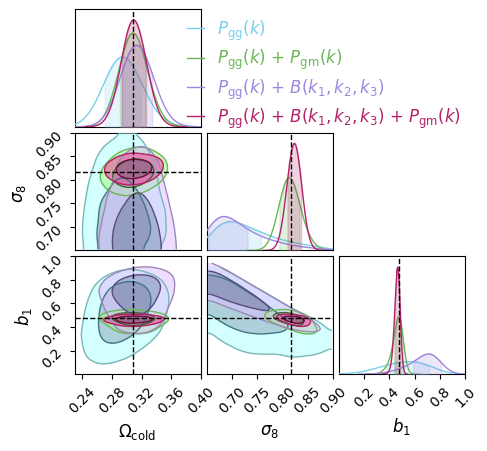

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig3_cosmic_variance_contours.png


<Figure size 640x480 with 0 Axes>

In [5]:
tags_inf, labels, colors, tags_test, keep, _, theta_show, _ = setup_fixed_mean_test()

plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep,
    theta_show=theta_show,
    extents=extents_contours,
    save_name="fig3_cosmic_variance_contours",
)


## 4. Coverage test — distributions

Fractional errors and error calibration ($\Delta\theta/\sigma$ vs Gaussian) for $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$. Uses full fiducial stat combo grid (four rows).

fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/re

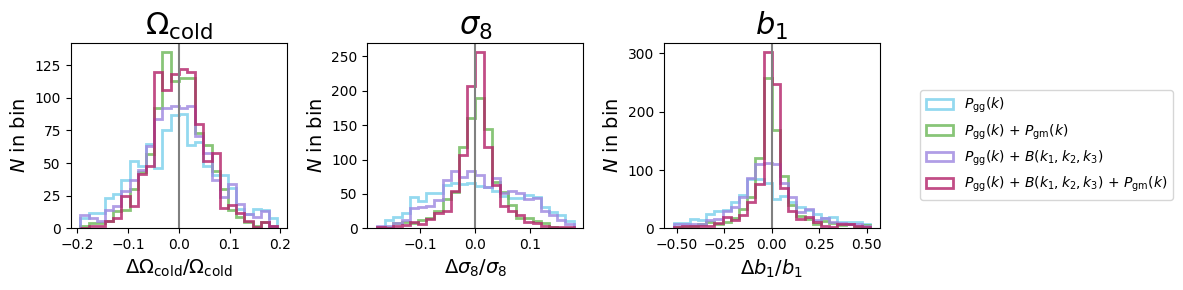

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig4_coverage_fractional_errors.png


<Figure size 640x480 with 0 Axes>

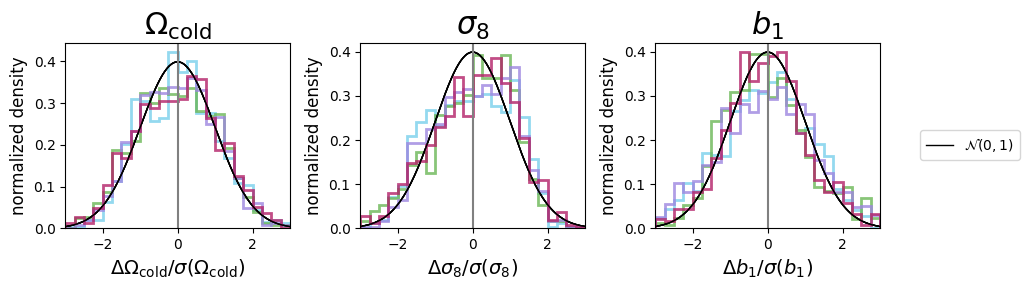

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig4_coverage_error_calibration.png


<Figure size 640x480 with 0 Axes>

In [25]:
tags_inf, labels, colors, tags_test, keep, cosmo_vary, bias_vary, param_vary = setup_coverage_test()
tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
tags_test_ok = [tags_test[i] for i, k in enumerate(keep) if k]
tags_inf_ok = [tags_inf[i] for i, k in enumerate(keep) if k]
labels_ok = [labels[i] for i, k in enumerate(keep) if k]
colors_ok = [colors[i] for i, k in enumerate(keep) if k]
stats_ok = [STATISTICS_ARR_FID[i] for i, k in enumerate(keep) if k]

theta_true_arr, theta_pred_arr, _, covs_pred_arr, _ = utils_plot.load_test_predictions(
    tags_inf=tags_inf_ok,
    tags_data_test=tags_test_ok,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    cosmo_param_names_vary=cosmo_vary,
    bias_param_names_vary=bias_vary,
    param_names_vary=param_vary,
    tag_reparam=tag_reparam,
    param_names_show=param_names_key_rp,
)
theta_true_arr, theta_pred_arr, covs_pred_arr = filter_finite_coverage_rows(
    theta_true_arr, theta_pred_arr, covs_pred_arr,
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr, theta_true_arr, param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_ok, label_arr=labels_ok,
    n_bins=25, alpha=0.8, histtype="step", xlim_auto=False,
    plot_cdf=False, unreparameterize=True,
    title=None,
)
save_current_figure("fig4_coverage_fractional_errors")

plotter.plot_dists_cov_subplots(
    theta_true_arr, theta_pred_arr, covs_pred_arr, param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_ok, label_arr=labels_ok,
    nbins=25, alpha=0.8, histtype="step", plot_cdf=False,
    unreparameterize=True,
    title=None,
)
save_current_figure("fig4_coverage_error_calibration")


## 5. Coverage test — predicted vs true

Predicted vs true with error bars for a random subsample ($N=100$ per stat combo). Grid: rows = statistics, columns = $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$.

/tmp/ipykernel_1190019/3006010970.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=2.2)


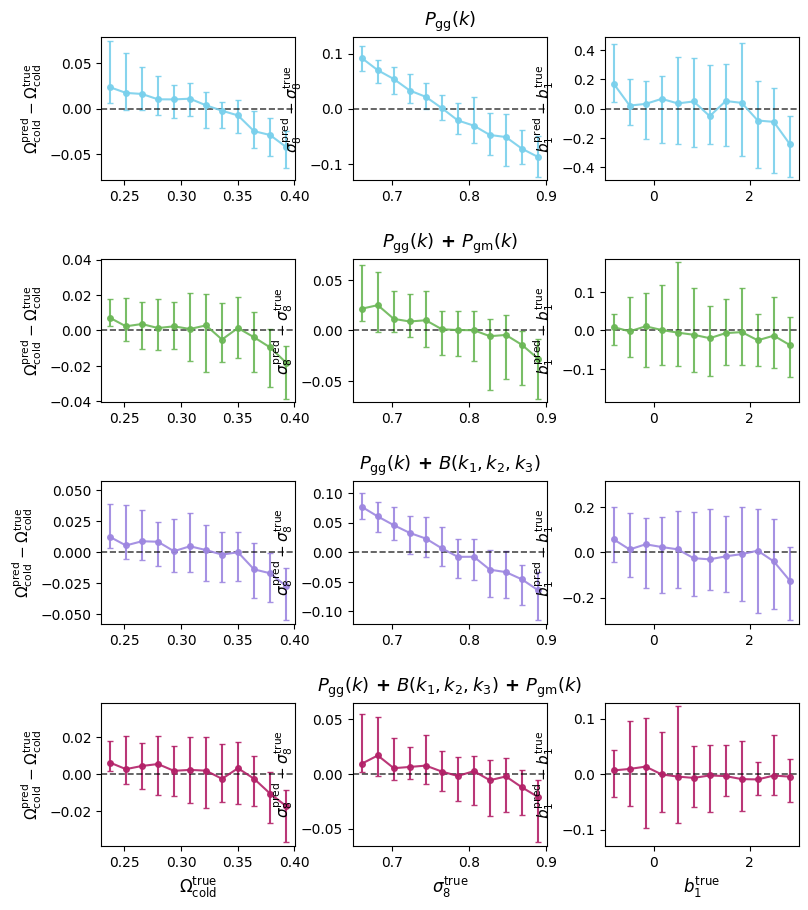

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig5alt_binned_diff.png


In [26]:
# Fig 5 alt (1): binned median (pred − true) vs true
import utils_inference

n_bins_alt = 12
param_names_plot = param_names_key
param_label_dict = utils_plot.param_label_dict
row_height = 2.625  # 50% taller than previous 1.75

# Unreparameterize to physical params (same as current fig 5)
theta_pred_u = theta_pred_arr.copy()
theta_true_u = theta_true_arr.copy()
covs_u = covs_pred_arr.copy()
names_u = list(param_names_key_rp)
for r in range(len(stats_ok)):
    tp, tt, covs, names_u = utils_inference.unreparameterize_prediction_block(
        theta_pred_u[r], theta_true_u[r], list(param_names_key_rp), covs_u[r],
    )
    theta_pred_u[r], theta_true_u[r], covs_u[r] = tp, tt, covs

idxs_plot = [names_u.index(pn) for pn in param_names_plot]
n_rows, n_cols = len(stats_ok), len(param_names_plot)
row_labels = [utils_plot.get_stat_label(s) for s in stats_ok]


def _param_latex_body(pn):
    """Strip surrounding $ from param_label_dict entry."""
    s = param_label_dict[pn]
    return s[1:-1] if s.startswith("$") and s.endswith("$") else s


def _binned_median_p1684(x, y, n_bins):
    """Bin y by x; return bin centers, median(y), and (p16, p84) for asymmetric errorbars."""
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    edges = np.linspace(np.min(x), np.max(x), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    medians = np.full(n_bins, np.nan)
    err_lo = np.full(n_bins, np.nan)
    err_hi = np.full(n_bins, np.nan)
    for i in range(n_bins):
        m = (x >= edges[i]) & (x < edges[i + 1] if i < n_bins - 1 else x <= edges[i + 1])
        if np.count_nonzero(m) == 0:
            continue
        p16, med, p84 = np.percentile(y[m], [16, 50, 84])
        medians[i] = med
        err_lo[i] = med - p16
        err_hi[i] = p84 - med
    return centers, medians, err_lo, err_hi


def _add_row_labels(fig, axes, y_pad=0.003):
    for r in range(n_rows):
        pos_left, pos_right = axes[r, 0].get_position(), axes[r, -1].get_position()
        fig.text(
            0.5 * (pos_left.x0 + pos_right.x1), pos_left.y1 + y_pad,
            row_labels[r], ha="center", va="bottom", fontsize=13, fontweight="bold",
        )


fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(3 * n_cols, row_height * n_rows),
    gridspec_kw={"hspace": 0.55, "wspace": 0.3},
)
axes = np.array(axes).reshape(n_rows, n_cols)
for r in range(n_rows):
    for c, pp in enumerate(idxs_plot):
        ax = axes[r, c]
        pn = param_names_plot[c]
        body = _param_latex_body(pn)
        true_vals = theta_true_u[r][:, pp]
        y_vals = theta_pred_u[r][:, pp] - true_vals
        centers, medians, err_lo, err_hi = _binned_median_p1684(
            true_vals, y_vals, n_bins_alt,
        )
        ax.errorbar(
            centers, medians, yerr=[err_lo, err_hi],
            fmt="o-", color=colors_ok[r], alpha=0.9,
            markersize=4, capsize=2, capthick=1, lw=1.5,
        )
        ax.axhline(0.0, color="k", ls="--", lw=1.2, alpha=0.7)
        # Symmetric ylim so zero is centered
        y_lo = np.nanmin(medians - err_lo)
        y_hi = np.nanmax(medians + err_hi)
        half = 1.05 * max(abs(y_lo), abs(y_hi), 1e-12)
        ax.set_ylim(-half, half)
        if r == n_rows - 1:
            ax.set_xlabel(rf"${body}^{{\mathrm{{true}}}}$", fontsize=12)
        # Per-column y label (each panel is a different parameter)
        ax.set_ylabel(
            rf"${body}^{{\mathrm{{pred}}}} - {body}^{{\mathrm{{true}}}}$",
            fontsize=11,
        )
plt.tight_layout(h_pad=2.2)
_add_row_labels(fig, axes, y_pad=0.003)
plt.show()
save_figure(fig, "fig5alt_binned_diff")


/tmp/ipykernel_1190019/1119413303.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


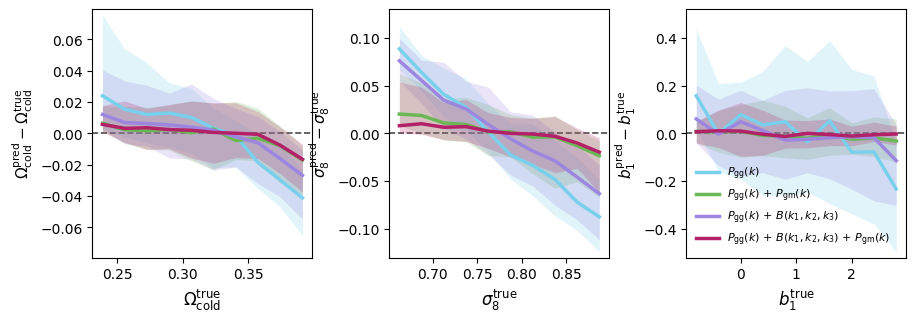

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig5alt_binned_diff_overlay.png


In [27]:
# Fig 5 alt (1b): binned diff overlay — all stats per param (shaded 16–84%)
n_bins_overlay = 10

fig, axes = plt.subplots(
    1, n_cols, figsize=(3.5 * n_cols, row_height + 0.6),
    gridspec_kw={"wspace": 0.35},
)
axes = np.atleast_1d(axes)

for c, pp in enumerate(idxs_plot):
    ax = axes[c]
    pn = param_names_plot[c]
    body = _param_latex_body(pn)

    # Shared x-edges from pooled truth range
    true_all = np.concatenate([theta_true_u[r][:, pp] for r in range(n_rows)])
    true_all = true_all[np.isfinite(true_all)]
    edges = np.linspace(np.min(true_all), np.max(true_all), n_bins_overlay + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    half = 0.0
    ax.axhline(0.0, color="k", ls="--", lw=1.2, alpha=0.7, zorder=1)
    for r in range(n_rows):
        true_vals = theta_true_u[r][:, pp]
        y_vals = theta_pred_u[r][:, pp] - true_vals
        ok = np.isfinite(true_vals) & np.isfinite(y_vals)
        x, y = true_vals[ok], y_vals[ok]
        medians = np.full(n_bins_overlay, np.nan)
        p16s = np.full(n_bins_overlay, np.nan)
        p84s = np.full(n_bins_overlay, np.nan)
        for i in range(n_bins_overlay):
            m = (x >= edges[i]) & (x < edges[i + 1] if i < n_bins_overlay - 1 else x <= edges[i + 1])
            if np.count_nonzero(m) == 0:
                continue
            p16, med, p84 = np.percentile(y[m], [16, 50, 84])
            medians[i] = med
            p16s[i] = p16
            p84s[i] = p84
        finite = np.isfinite(medians)
        if np.any(finite):
            half = max(half, float(np.nanmax(np.abs(p16s[finite]))), float(np.nanmax(np.abs(p84s[finite]))))
            ax.fill_between(
                centers[finite], p16s[finite], p84s[finite],
                color=colors_ok[r], alpha=0.22, linewidth=0, zorder=2,
            )
            ax.plot(
                centers[finite], medians[finite],
                color=colors_ok[r], lw=2.5, label=row_labels[r], zorder=3,
            )

    ax.set_ylim(-1.05 * max(half, 1e-12), 1.05 * max(half, 1e-12))
    ax.set_xlabel(rf"${body}^{{\mathrm{{true}}}}$", fontsize=12)
    ax.set_ylabel(
        rf"${body}^{{\mathrm{{pred}}}} - {body}^{{\mathrm{{true}}}}$",
        fontsize=11,
    )
    if c == n_cols - 1:
        ax.legend(fontsize=8, loc="best", frameon=False)

plt.tight_layout()
plt.show()
save_figure(fig, "fig5alt_binned_diff_overlay")


/tmp/ipykernel_1190019/1697041798.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=2.2)


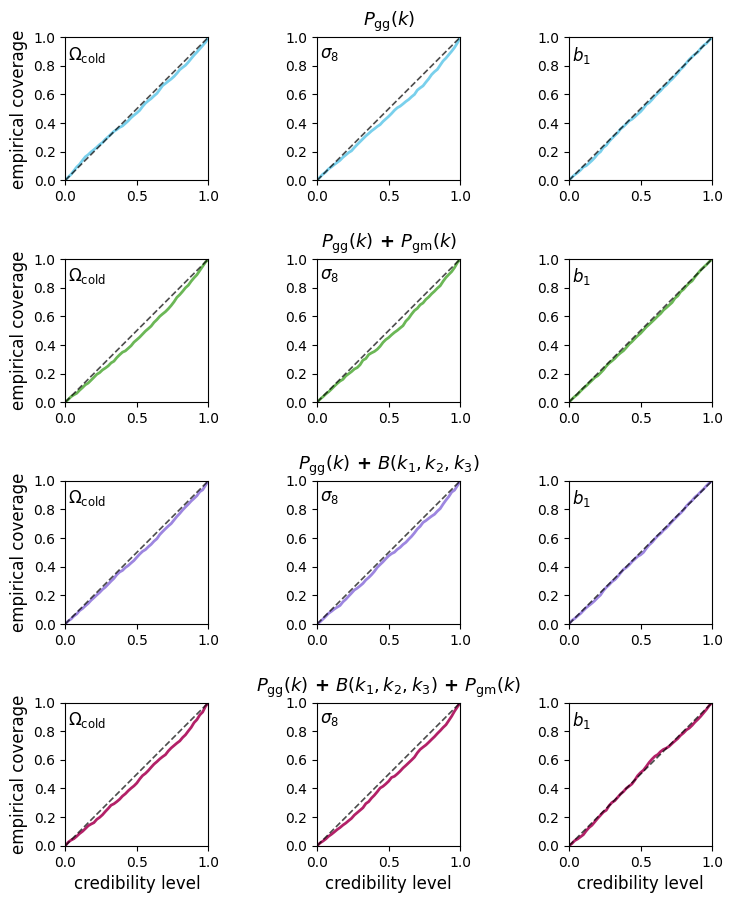

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig5alt_pp_credibility.png


In [28]:
# Fig 5 alt (2): PP plot — nominal credibility vs empirical coverage
# Speedy path: mmap + load only the 3 key columns (files are ~0.44 GB × 11 params).

cred_levels = np.linspace(0.0, 1.0, 51)

# Truth once (shared across all stat combos)
theta_test_all = data_loader.load_theta_test(
    TAG_PARAMS_TEST_COV,
    TAG_BIASPARAMS_TEST_COV,
    cosmo_param_names_vary=cosmo_vary,
    bias_param_names_vary=bias_vary,
)
if tag_reparam:
    theta_test_all, names_theta = utils_inference.reparameterize_theta(
        theta_test_all, list(param_vary),
    )
else:
    names_theta = list(param_vary)
names_theta = list(names_theta)

# Columns needed: key params in sample space (+ product for unreparam of b1)
# samples store b1 as sigma8_cold_x_b1 under reparam
names_need_rp = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]


def _load_key_samples(tag_inf, tag_test):
    """mmap file and materialize only needed columns → ~3/11 of I/O."""
    dir_sbi = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}"
    fn = dir_sbi / f"samples_test{tag_test}_pred.npy"
    names_samp = list(np.loadtxt(dir_sbi / "param_names.txt", dtype=str))
    idxs = [names_samp.index(pn) for pn in names_need_rp]
    mm = np.load(fn, mmap_mode="r")
    if mm.ndim == 2:
        # (n_draws, n_params) → single obs
        sub = np.asarray(mm[:, idxs], dtype=np.float64)[:, None, :]
    else:
        sub = np.asarray(mm[:, :, idxs], dtype=np.float64)  # (n_draws, n_obs, 3)
    return sub  # columns = names_need_rp


def _physical_from_rp(arr):
    """arr[..., 0]=omega, 1=s8, 2=s8*b1 → physical omega, s8, b1."""
    out = np.empty_like(arr)
    out[..., 0] = arr[..., 0]
    out[..., 1] = arr[..., 1]
    out[..., 2] = arr[..., 2] / arr[..., 1]  # b1
    return out


def _ranks(samples_do, truth_o):
    """PIT ranks, samples (n_draws, n_obs), truth (n_obs,)."""
    return np.mean(samples_do < truth_o[np.newaxis, :], axis=0)


def _emp_coverage(ranks, cred_levels):
    # α_min that covers truth = 2|r-0.5|; ECDF of that vs nominal credibility
    a_min = 2.0 * np.abs(ranks[np.isfinite(ranks)] - 0.5)
    a_min.sort()
    n = a_min.size
    # fraction with a_min <= α
    return np.searchsorted(a_min, cred_levels, side="right") / n


# Precompute truth columns in reparam space, then physical
i_t = [names_theta.index(pn) for pn in names_need_rp]
theta_rp = theta_test_all[:, i_t]  # (n_obs, 3)
theta_phys_all = _physical_from_rp(theta_rp)

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(3 * n_cols, row_height * n_rows),
    gridspec_kw={"hspace": 0.55, "wspace": 0.3},
)
axes = np.array(axes).reshape(n_rows, n_cols)

# pp_emp_arr[r, c, :] = empirical coverage vs cred_levels for stat r, param c
pp_emp_arr = np.full((n_rows, n_cols, cred_levels.size), np.nan)

for r in range(n_rows):
    samples_rp = _load_key_samples(tags_inf_ok[r], tags_test_ok[r])
    # Drop failed obs: non-finite mean over draws
    ok = np.all(np.isfinite(samples_rp.mean(axis=0)), axis=1)
    samples_phys = _physical_from_rp(samples_rp[:, ok, :])
    theta_phys = theta_phys_all[ok]

    for c in range(n_cols):
        ax = axes[r, c]
        ranks = _ranks(samples_phys[:, :, c], theta_phys[:, c])
        emp = _emp_coverage(ranks, cred_levels)
        pp_emp_arr[r, c] = emp
        ax.plot(cred_levels, emp, color=colors_ok[r], lw=2.0)
        ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.text(
            0.02, 0.95, rf"{param_label_dict[param_names_plot[c]]}",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=12, fontweight="bold",
        )
        if r == n_rows - 1:
            ax.set_xlabel("credibility level", fontsize=12)
        if c == 0:
            ax.set_ylabel("empirical coverage", fontsize=12)

plt.tight_layout(h_pad=2.2)
_add_row_labels(fig, axes)
plt.show()
save_figure(fig, "fig5alt_pp_credibility")


/tmp/ipykernel_1190019/3274443854.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


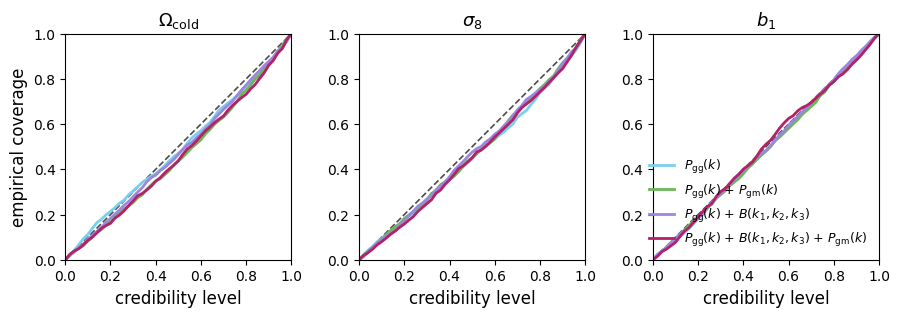

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig5alt_pp_credibility_overlay.png


In [29]:
# Fig 5 alt (2b): PP plot overlay — all stat combos on one panel per parameter
# Uses pp_emp_arr cached by the cell above (re-run that cell first if missing).

fig, axes = plt.subplots(
    1, n_cols, figsize=(3.5 * n_cols, row_height + 0.4),
    gridspec_kw={"wspace": 0.3},
)
axes = np.atleast_1d(axes)

for c in range(n_cols):
    ax = axes[c]
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.7, zorder=1)
    for r in range(n_rows):
        ax.plot(
            cred_levels, pp_emp_arr[r, c],
            color=colors_ok[r], lw=2.0, label=row_labels[r], zorder=2,
        )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("credibility level", fontsize=12)
    if c == 0:
        ax.set_ylabel("empirical coverage", fontsize=12)
    ax.set_title(rf"{param_label_dict[param_names_plot[c]]}", fontsize=13, fontweight="bold")
    if c == n_cols - 1:
        ax.legend(fontsize=9, loc="lower right", frameon=False)

plt.tight_layout()
plt.show()
save_figure(fig, "fig5alt_pp_credibility_overlay")


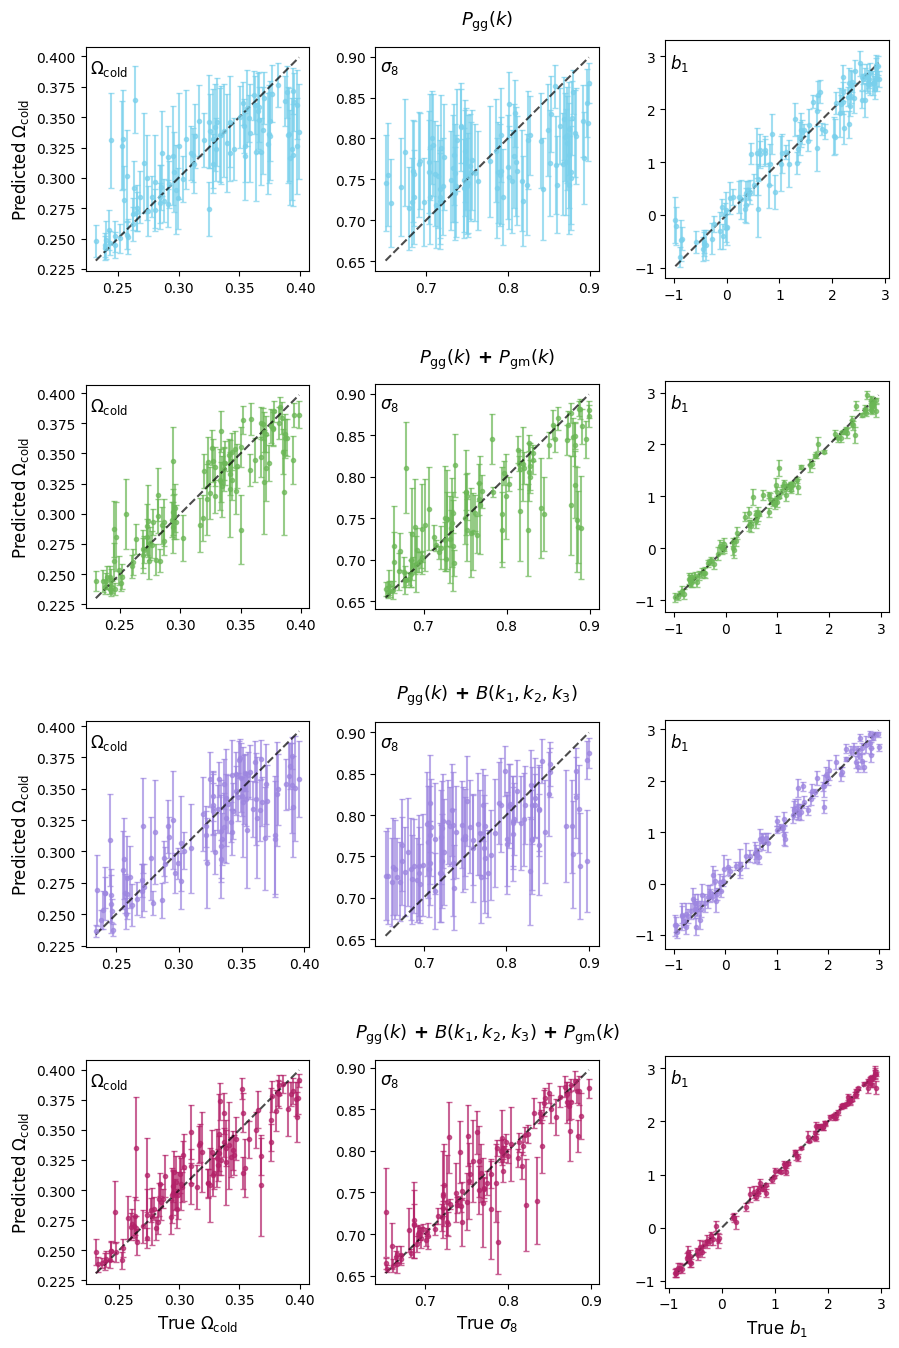

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig5_coverage_predicted_vs_true.png


<Figure size 640x480 with 0 Axes>

In [30]:
plotter.plot_comp_mean_subplots_grid(
    stats_ok,
    theta_pred_arr, theta_true_arr, covs_pred_arr,
    param_names=param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_ok, label_arr=labels_ok,
    alpha=0.7, N_plot=100, unreparameterize=True,
    title=None,
)
save_current_figure("fig5_coverage_predicted_vs_true")


## 6. SHAMe test

OOD galaxy catalog ($\bar n = 0.00022\,h^3/\mathrm{Mpc}^3$). Contours for all fiducial statistics combinations.

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022_pred.npy


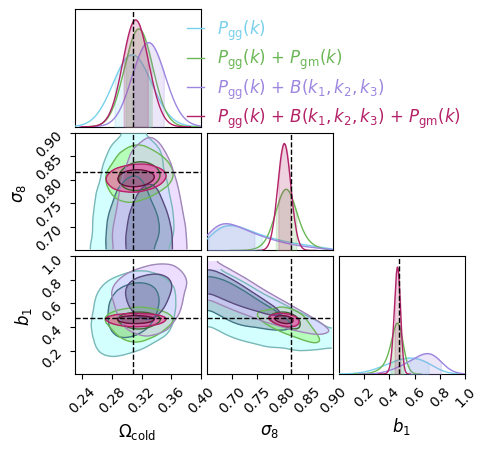

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig6_shame_contours.png


<Figure size 640x480 with 0 Axes>

In [8]:
tags_inf, labels, colors, tags_test, keep, param_vary, theta_show = setup_shame_test()

plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep,
    theta_show=theta_show,
    extents=extents_contours,
    save_name="fig6_shame_contours",
)


## 7. Convergence: $P_{gg}+B+P_{gm}$ (3D FoM / FoB)

Coverage-test 3D FoM and normalized FoB vs $N_\mathrm{train} = n_\mathrm{cosmo} \times n_\mathrm{bias}$ ($= n_\mathrm{train} \times b_x$ on the grid). FoB is plotted as FoB/$\chi^2_{\nu=3}(0.68)$; dashed line at 1 = $1\sigma$. Curves connect fixed $n_\mathrm{cosmo}$ across $b_x$; opacity $\propto n_\mathrm{cosmo}$. Full grid: `2026-06-05_convergence_ntrain_bx.ipynb`.

In [7]:
import pandas as pd
import utils_inference as ui
from scipy.stats import chi2

statistics_full = ["pk", "bispec", "pgm"]
tag_masks_full = "_kb0.25_kpgm0.25"
n_cosmo_arr = [500, 1000, 2000, 4000, 6000, 8000, 10000]
bx_arr = [1, 2, 4, 8, 16, 32]
N_COVERAGE = 1000

PARAM_NAMES_FOB = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]
FOB_KEYS = ["omega_m", "sigma8", "sigma8_b1"]
FOB_LABELS = {
    "omega_m": r"$\Omega_\mathrm{c}$",
    "sigma8": r"$\sigma_8$",
    "sigma8_b1": r"$\sigma_8 b_1$",
}
_CHI2_PPF_1SIG = 0.682689492137
FOB_RIDGE = 1e-8
NCOSMO_ALPHA_LO, NCOSMO_ALPHA_HI = 0.15, 1.0
XLABEL_NSIMS = r"$N_\mathrm{train}$ ($= N_\mathrm{cosmo} \times N_\mathrm{bias}$)"
STAT_LABELS_SHORT = {
    "pk": r"$P_\mathrm{gg}$",
    "bispec": r"$B$",
    "pgm": r"$P_\mathrm{gm}$",
}


def get_stat_label_short(statistics):
    return " + ".join(STAT_LABELS_SHORT[s] for s in statistics)


def fob_chi2_sqrt_limit(ndims):
    return float(np.sqrt(chi2.ppf(_CHI2_PPF_1SIG, int(ndims))))


FOB3_YLABEL = r"FoB/$\chi^2_{\nu=3}(0.68)$"


def compute_fob(theta_pred_row, cov, param_names, theta_true, param_vary):
    names = list(param_names)
    theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
    names_rep = list(names_rep)
    true_fob = np.array(
        [theta_true_rep[names_rep.index(pn)] for pn in PARAM_NAMES_FOB], dtype=float,
    )
    mu = np.array(
        [float(theta_pred_row[names.index(pn)]) for pn in PARAM_NAMES_FOB], dtype=float,
    )
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    cov_sub = np.asarray(cov, dtype=float)[np.ix_(idx_fob, idx_fob)] + FOB_RIDGE * np.eye(len(idx_fob))
    fob = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fob[key] = abs(mu[i] - true_fob[i]) / sig if sig > 0 else np.nan
    diff = mu - true_fob
    sign, logdet = np.linalg.slogdet(cov_sub)
    cov_inv = np.linalg.inv(cov_sub) if sign > 0 else np.linalg.pinv(cov_sub)
    fob3 = float(np.sqrt(diff @ cov_inv @ diff))
    return fob, fob3


def compute_fom_key_block(cov, param_names):
    names = list(param_names)
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    cov_sub = np.asarray(cov, dtype=float)[np.ix_(idx_fob, idx_fob)]
    fom_marg = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fom_marg[key] = 1.0 / sig if sig > 0 else np.nan
    det = np.linalg.det(cov_sub)
    fom_3d = 1.0 / np.sqrt(det) if det > 0 else np.nan
    return fom_marg, float(fom_3d)


def build_tag_inf_conv(bx_val, n_cosmo_val, statistics, tag_masks):
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}{TAG_PARAMS_TRAIN}"
        f"{TAG_BIASPARAMS_TRAIN}{TAG_NOISE_TRAIN}{tag_reparam}"
        f"_bx{bx_val}_ntrain{n_cosmo_val}{TAG_INF_BEST_SUFFIX}"
    )


def build_tag_test_conv(statistics, tag_masks):
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}"
        f"{TAG_PARAMS_TEST_COV}{TAG_BIASPARAMS_TEST_COV}{TAG_NOISE_TEST_COV}"
    )


def _coverage_samples_path(tag_inf, tag_test):
    """Return (path, kind) with kind in {'done', 'inprogress'}, or (None, None)."""
    base = dir_sbi / f"sbi{tag_inf}"
    fn = base / f"samples_test{tag_test}_pred.npy"
    if fn.is_file():
        return fn, "done"
    fn_ip = base / f"samples_test{tag_test}_pred_inprogress.npy"
    if fn_ip.is_file():
        return fn_ip, "inprogress"
    return None, None


def _finite_sample_rows(samples_arr):
    """Indices of coverage rows with finite posterior chains (failed batches are all-NaN)."""
    if samples_arr.ndim != 3:
        raise ValueError(f"expected 3D samples, got {samples_arr.shape}")
    # Skip all-NaN obs before nanmean to avoid "Mean of empty slice" warnings.
    has_any = np.any(np.isfinite(samples_arr), axis=(0, 2))
    n_obs, n_par = samples_arr.shape[1], samples_arr.shape[2]
    theta_pred = np.full((n_obs, n_par), np.nan, dtype=float)
    if np.any(has_any):
        theta_pred[has_any] = np.nanmean(samples_arr[:, has_any, :], axis=0)
    return np.where(np.all(np.isfinite(theta_pred), axis=1))[0]


def _moments_from_samples_3d(samples_arr, param_names):
    rows = _finite_sample_rows(samples_arr)
    npar = samples_arr.shape[2]
    if rows.size == 0:
        return np.empty((0, npar)), np.empty((0, npar, npar)), list(param_names), rows
    theta_pred = np.array([np.nanmean(samples_arr[:, i, :], axis=0) for i in rows])
    covs_pred = np.array([np.cov(samples_arr[:, i, :].T) for i in rows])
    return theta_pred, covs_pred, list(param_names), rows


def load_coverage_metrics(bx, n_cosmo, statistics, tag_masks, tag_test=None):
    """
    Load FoM/FoB metrics for one grid point.

    Returns
    -------
    row : dict or None
    info : dict with keys status, message, path, n_stored, n_cov, kind
    """
    if tag_test is None:
        tag_test = build_tag_test_conv(statistics, tag_masks)
    tag_inf = build_tag_inf_conv(bx, n_cosmo, statistics, tag_masks)
    label = utils_plot.get_stat_label(statistics)
    base_info = {
        "label": label, "bx": bx, "n_cosmo": n_cosmo,
        "tag_inf": tag_inf, "path": None, "kind": None,
        "n_stored": 0, "n_cov": 0, "status": "missing", "message": "",
    }

    model_dir = dir_sbi / f"sbi{tag_inf}"
    if not model_dir.is_dir():
        base_info["message"] = f"no model directory: {model_dir.name}"
        return None, base_info

    fn, kind = _coverage_samples_path(tag_inf, tag_test)
    base_info["kind"] = kind
    if fn is None:
        base_info["message"] = (
            f"no coverage samples "
            f"(looked for samples_test…_pred.npy / _pred_inprogress.npy under {model_dir.name})"
        )
        return None, base_info

    base_info["path"] = str(fn)
    samples_arr = np.load(fn)
    fn_pn = model_dir / "param_names.txt"
    if not fn_pn.is_file():
        base_info["status"] = "bad_model"
        base_info["message"] = f"missing param_names.txt in {model_dir.name} (file={fn.name})"
        return None, base_info
    if samples_arr.ndim != 3:
        base_info["status"] = "bad_shape"
        base_info["message"] = f"expected 3D samples (n_draw, n_obs, n_par), got shape={samples_arr.shape} from {fn.name}"
        return None, base_info

    n_stored = int(samples_arr.shape[1])
    base_info["n_stored"] = n_stored
    if n_stored == 0:
        base_info["status"] = "empty"
        base_info["message"] = f"samples file has n_obs=0: {fn.name}"
        return None, base_info

    param_names_all = np.loadtxt(fn_pn, dtype=str)
    theta_pred, covs_pred, param_names, rows = _moments_from_samples_3d(samples_arr, param_names_all)
    n_use = int(rows.size)
    base_info["n_cov"] = n_use
    n_nan_rows = n_stored - n_use

    if n_use == 0:
        base_info["status"] = "all_nan"
        base_info["message"] = (
            f"loaded {fn.name} ({kind}): shape={samples_arr.shape}, "
            f"but all {n_stored} stored obs are all-NaN / unusable"
        )
        return None, base_info

    if kind == "inprogress" or n_stored < N_COVERAGE or n_use < N_COVERAGE:
        status = "incomplete"
        parts = [f"loaded {fn.name} ({kind})", f"shape={tuple(samples_arr.shape)}"]
        parts.append(f"usable={n_use}/{N_COVERAGE} target")
        if n_stored != n_use:
            parts.append(f"stored={n_stored} ({n_nan_rows} all-NaN/failed rows dropped)")
        if kind == "inprogress":
            parts.append("still inprogress — final _pred.npy not written yet")
        elif n_stored < N_COVERAGE:
            parts.append(f"file truncated: only {n_stored} obs stored")
        base_info["status"] = status
        base_info["message"] = "; ".join(parts)
    else:
        base_info["status"] = "complete"
        base_info["message"] = (
            f"loaded {fn.name} (done): usable={n_use}/{N_COVERAGE}"
            + (f" (dropped {n_nan_rows} failed rows)" if n_nan_rows else "")
        )

    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    theta_true_all = data_loader.load_theta_test(
        TAG_PARAMS_TEST_COV, TAG_BIASPARAMS_TEST_COV,
        cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
    )
    if theta_true_all.ndim == 1:
        theta_true_all = np.tile(theta_true_all, (samples_arr.shape[1], 1))
    theta_true_all = theta_true_all[rows]

    fob_lists = {key: [] for key in FOB_KEYS}
    fom_marg_lists = {key: [] for key in FOB_KEYS}
    fob3_list = []
    fom_3d_list = []
    for i in range(n_use):
        fob, fob3 = compute_fob(theta_pred[i], covs_pred[i], param_names, theta_true_all[i], param_vary)
        fom_marg, fom_3d = compute_fom_key_block(covs_pred[i], param_names)
        for key in FOB_KEYS:
            fob_lists[key].append(fob[key])
            fom_marg_lists[key].append(fom_marg[key])
        fob3_list.append(fob3)
        fom_3d_list.append(fom_3d)

    row = {
        "bx": bx, "n_cosmo": n_cosmo, "n_sims": bx * n_cosmo,
        "n_cov": n_use, "n_stored": n_stored, "status": base_info["status"],
        "kind": kind,
    }
    for key in FOB_KEYS:
        row[f"fom_{key}"] = float(np.nanmean(fom_marg_lists[key]))
        row[f"fob_{key}"] = float(np.nanmean(fob_lists[key]))
    row["fom_3d"] = float(np.nanmean(fom_3d_list))
    row["fob3"] = float(np.nanmean(fob3_list))
    return row, base_info


def collect_coverage_grid(statistics, tag_masks, n_cosmo_values, bx_values, *, verbose=True):
    tag_test = build_tag_test_conv(statistics, tag_masks)
    label = utils_plot.get_stat_label(statistics)
    rows = []
    n_complete = n_incomplete = n_missing = 0
    if verbose:
        print(f"=== Coverage grid: {label} ===")
        print(f"tag_test = {tag_test}")
        print(f"grid: {len(bx_values)} bx × {len(n_cosmo_values)} n_cosmo = {len(bx_values) * len(n_cosmo_values)} points\n")

    for bx in bx_values:
        for n_cosmo in n_cosmo_values:
            m, info = load_coverage_metrics(
                bx, n_cosmo, statistics, tag_masks, tag_test=tag_test,
            )
            prefix = f"[{label}] bx={bx}, n_cosmo={n_cosmo}"
            if m is None:
                n_missing += 1
                if verbose:
                    print(f"MISSING  {prefix}: {info['message']}")
                continue
            rows.append(m)
            if info["status"] == "complete":
                n_complete += 1
                if verbose:
                    print(f"OK       {prefix}: {info['message']}")
            else:
                n_incomplete += 1
                if verbose:
                    print(f"INCOMPLETE {prefix}: {info['message']}")

    n_expected = len(bx_values) * len(n_cosmo_values)
    if verbose:
        print(
            f"\nSummary [{label}]: {len(rows)} loaded "
            f"({n_complete} complete, {n_incomplete} incomplete) / {n_expected} expected; "
            f"{n_missing} missing\n"
        )
    return pd.DataFrame(rows) if rows else pd.DataFrame()


In [4]:
def n_cosmo_alpha(n_cosmo, n_cosmo_values=None, lo=NCOSMO_ALPHA_LO, hi=NCOSMO_ALPHA_HI):
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else n_cosmo_arr)
    if len(n_cosmo_values) == 1:
        return hi
    t = n_cosmo_values.index(int(n_cosmo)) / (len(n_cosmo_values) - 1)
    return lo + t * (hi - lo)


def _draw_nsims_curves(ax, df, y_col, color, *, n_cosmo_values=None, y_scale=1.0):
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else df["n_cosmo"].unique())
    rgb = mcolors.to_rgb(color)
    for n_cosmo in n_cosmo_values:
        grp = df[df["n_cosmo"] == n_cosmo].sort_values("n_sims")
        if grp.empty or y_col not in grp.columns:
            continue
        rgba = (*rgb, n_cosmo_alpha(n_cosmo, n_cosmo_values))
        if len(grp) >= 1:
            ax.plot(grp["n_sims"], grp[y_col] / y_scale, color=rgba, ls="-", lw=1.5, zorder=1)


def _n_cosmo_legend_handles(n_cosmo_values):
    handles, labels = [], []
    for n_cosmo in sorted(n_cosmo_values):
        alpha = n_cosmo_alpha(n_cosmo, n_cosmo_values)
        handles.append(plt.Line2D([0], [0], color=(0.5, 0.5, 0.5, alpha), ls="-", lw=1.5))
        labels.append(rf"$N_\mathrm{{cosmo}}={n_cosmo}$")
    return handles, labels


def _conv_legend_outside(fig, stat_handles=None, stat_labels=None, n_cosmo_values=None):
    handles, labels = [], []
    if stat_handles is not None:
        handles.extend(stat_handles)
        labels.extend(stat_labels)
    if n_cosmo_values is not None:
        h_nc, l_nc = _n_cosmo_legend_handles(n_cosmo_values)
        handles.extend(h_nc)
        labels.extend(l_nc)
    fig.legend(
        handles, labels, fontsize=8, loc="center left",
        bbox_to_anchor=(1.0, 0.5), frameon=False,
    )
    fig.subplots_adjust(right=0.90)


def plot_conv_fom3d_fob3_nsims(
    df,
    color,
    *,
    n_cosmo_values=None,
    save_name=None,
):
    if df.empty:
        print("No data for convergence plot")
        return
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else df["n_cosmo"].unique())
    ref3 = fob_chi2_sqrt_limit(3)
    fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
    _draw_nsims_curves(axes[0], df, "fom_3d", color, n_cosmo_values=n_cosmo_values)
    axes[0].set_ylabel(r"FoM$_3$")
    axes[0].set_yscale("log")
    axes[0].set_xscale("log")
    _draw_nsims_curves(
        axes[1], df, "fob3", color, n_cosmo_values=n_cosmo_values, y_scale=ref3,
    )
    h_ref = axes[1].axhline(1.0, color="gray", ls=":", lw=1, alpha=0.7, label=r"$1\sigma$")
    axes[1].set_ylabel(FOB3_YLABEL)
    axes[1].set_xscale("log")
    axes[1].set_xlabel(XLABEL_NSIMS)
    h_nc, l_nc = _n_cosmo_legend_handles(n_cosmo_values)
    axes[0].legend(h_nc, l_nc, fontsize=8, loc="best", frameon=False)
    axes[1].legend(handles=[h_ref], labels=[r"$1\sigma$"], fontsize=8, loc="best", frameon=False)
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_conv_all_combos_nsims(df_all, *, save_name=None):
    if df_all.empty:
        print("No data for convergence plot")
        return
    full_labels = [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID]
    short_labels = [get_stat_label_short(s) for s in STATISTICS_ARR_FID]
    n_cosmo_values = sorted(df_all["n_cosmo"].unique())
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    for ax, key in zip(axes[0], FOB_KEYS):
        for full_label, color in zip(full_labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == full_label]
            _draw_nsims_curves(ax, sub, f"fom_{key}", color, n_cosmo_values=n_cosmo_values)
        ax.set_ylabel("FoM")
        ax.set_yscale("log")
        ax.set_xscale("log")
    for ax, key in zip(axes[1], FOB_KEYS):
        for full_label, color in zip(full_labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == full_label]
            _draw_nsims_curves(ax, sub, f"fob_{key}", color, n_cosmo_values=n_cosmo_values)
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7)
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7)
        ax.set_ylabel("FoB")
        ax.set_xscale("log")
    fob_vals = []
    for key in FOB_KEYS:
        col = f"fob_{key}"
        if col in df_all.columns:
            fob_vals.extend(df_all[col].dropna().tolist())
    if fob_vals:
        ymin, ymax = float(np.nanmin(fob_vals)), float(np.nanmax(fob_vals))
        pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.1
        fob_ylim = (max(0.0, ymin - pad), ymax + pad)
        for ax in axes[1]:
            ax.set_ylim(fob_ylim)
    for ax in axes[1]:
        ax.set_xlabel(XLABEL_NSIMS)
    stat_handles = [
        plt.Line2D([0], [0], color=c, ls="-", lw=1.5)
        for c in COLORS_FID
    ]
    fig.tight_layout()
    _conv_legend_outside(
        fig, stat_handles=stat_handles, stat_labels=short_labels,
        n_cosmo_values=n_cosmo_values,
    )
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


In [8]:
# Slow: loads coverage samples for each (n_cosmo, bx) on the grid.
df_conv_full = collect_coverage_grid(statistics_full, tag_masks_full, n_cosmo_arr, bx_arr)
print(f"$P_{{gg}}+B+P_{{gm}}$: {len(df_conv_full)} grid points loaded")


=== Coverage grid: $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ ===
tag_test = _muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000
grid: 6 bx × 7 n_cosmo = 42 points

OK       [$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$] bx=1, n_cosmo=500: loaded samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy (done): usable=1000/1000
OK       [$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$] bx=1, n_cosmo=1000: loaded samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy (done): usable=1000/1000
INCOMPLETE [$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$] bx=1, n_cosmo=2000: loaded samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pre

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig7_convergence_pgg_b_pgm.png


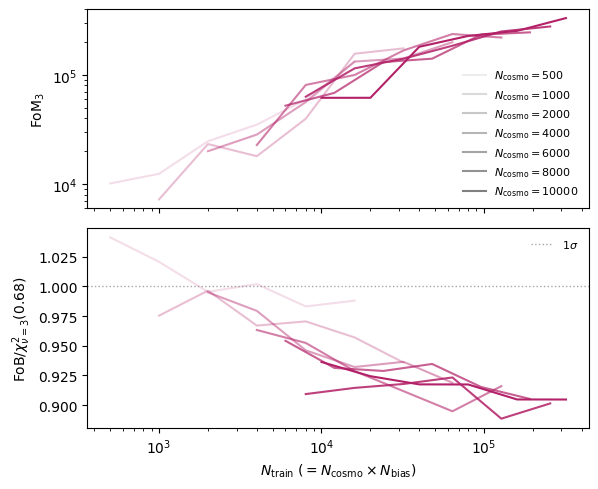

In [12]:
plot_conv_fom3d_fob3_nsims(
    df_conv_full,
    COLORS_FID[3],
    save_name="fig7_convergence_pgg_b_pgm",
)


## 8. Convergence: all stat combos (marginal FoM / FoB)

Coverage-test marginal FoM / FoB vs $N_\mathrm{train}$ for each fiducial statistics combination ($\Omega_\mathrm{c}$, $\sigma_8$, $\sigma_8 b_1$). Same $N_\mathrm{train}$ grid as Fig. 7; curves connect fixed $n_\mathrm{cosmo}$ across $b_x$.

In [13]:
# Slow: same grid for all four fiducial stat combos.
frames = []
for statistics, tag_masks, label in zip(
    STATISTICS_ARR_FID, TAGS_MASK_FID,
    [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID],
):
    df = collect_coverage_grid(statistics, tag_masks, n_cosmo_arr, bx_arr)
    if df.empty:
        print(f"No coverage grid for {label}")
        continue
    df = df.copy()
    df["stat_combo"] = label
    frames.append(df)
    print(f"{label}: {len(df)} grid points loaded")
df_conv_all = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)


$P_\mathrm{gg}(k)$: 42 grid points loaded


/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipy

$P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$: 42 grid points loaded


/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)


Missing: $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$, bx=4, n_cosmo=2000


/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)


$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$: 41 grid points loaded


/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)
/tmp/ipykernel_459134/3664776957.py:106: RuntimeWarning: Mean of empty slice
  theta_pred = np.nanmean(samples_arr, axis=0)


$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$: 42 grid points loaded


Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig8_convergence_all_combos.png


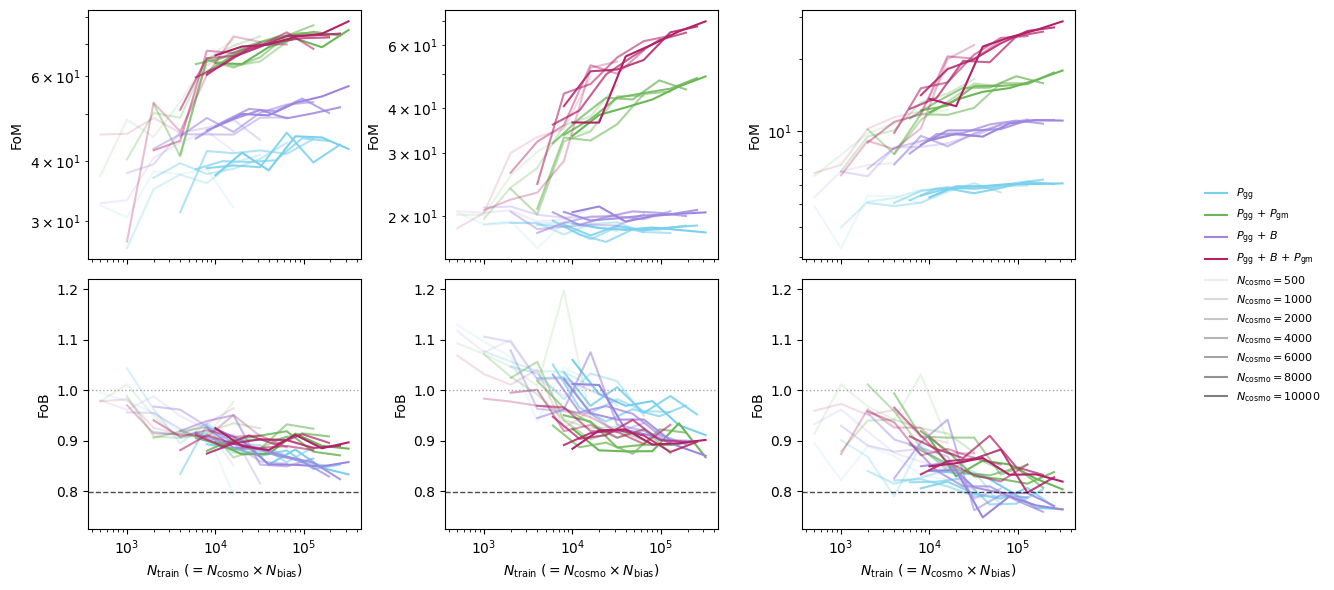

In [14]:
plot_conv_all_combos_nsims(df_conv_all, save_name="fig8_convergence_all_combos")


## 9. Scale dependence of constraints

SHAMe OOD: normalized 3D FoB, FoB/$\chi^2_{\nu=3}(0.68)$ ($P{=}3$ key block: $\Omega_\mathrm{c}$, $\sigma_8$, $\sigma_8 b_1$) for the three statistics combinations that include bispec and/or PGM ($P_{gg}$ fixed at $k_\mathrm{max}{=}0.4$). Top panel: PGM $k_\mathrm{max}$ fixed at $0.25$, bispec $k_\mathrm{max}$ on the $x$-axis; bottom panel: bispec $k_\mathrm{max}$ fixed at $0.25$, PGM $k_\mathrm{max}$ on the $x$-axis. Dashed line at 1 = $1\sigma$.

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/fig9_scale_dependence_fob3.png


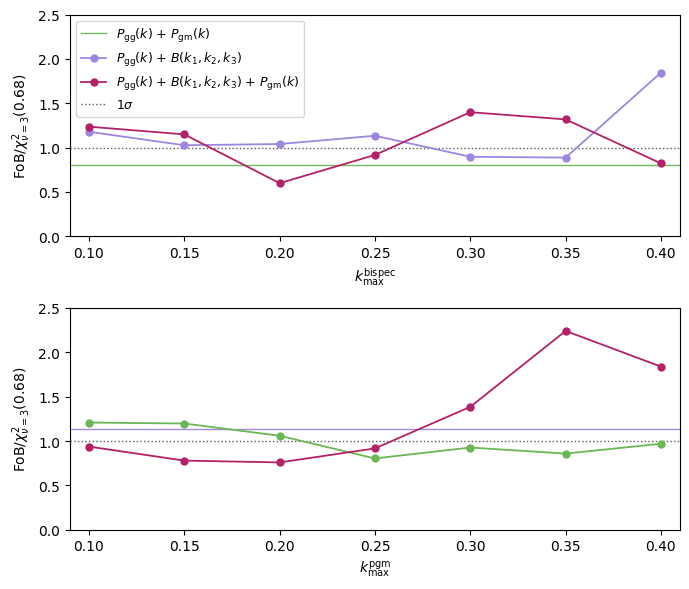

In [8]:
TAGS_KMAX_KPGM = ["_kpgm0.1", "_kpgm0.15", "_kpgm0.2", "_kpgm0.25", "_kpgm0.3", "_kpgm0.35", ""]
TAGS_KMAX_KB = ["_kb0.1", "_kb0.15", "_kb0.2", "_kb0.25", "_kb0.3", "_kb0.35", ""]
STAT_COMBOS_SCALE = [
    (["pk", "pgm"], COLORS_FID[1]),
    (["pk", "bispec"], COLORS_FID[2]),
    (["pk", "bispec", "pgm"], COLORS_FID[3]),
]
KMAX_PK = KMAX_LOOSE


def kmax_kb_numeric(tag_kb):
    if tag_kb == "":
        return KMAX_PK
    return float(tag_kb.replace("_kb", ""))


def kmax_kpgm_numeric(tag_kpgm):
    if tag_kpgm == "":
        return KMAX_PK
    return float(tag_kpgm.replace("_kpgm", ""))


def _mask_candidates_kb(tag_kb):
    if tag_kb == "":
        return ["", "_kb0.4"]
    return [tag_kb]


def _joined_kb_kpgm(tag_kb, tag_kpgm):
    return f"{tag_kb}{tag_kpgm}"


def _joint_mask_candidates(tag_kb, tag_kpgm):
    out = [_joined_kb_kpgm(tag_kb, tag_kpgm)]
    if tag_kb == "":
        alt = _joined_kb_kpgm("_kb0.4", tag_kpgm)
        if alt not in out:
            out.append(alt)
    return out


def _shame_samples_path(statistics_row, tag_mask):
    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=[statistics_row],
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask],
    )
    tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
    tag_stats = f"_{'_'.join(statistics_row)}"
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=[tag_stats],
        tags_mask=[tag_mask],
        tag_mock=TAG_MOCK_SHAME,
        data_mode_test=DATA_MODE_TEST_SHAME,
    )
    fn = dir_sbi / f"sbi{tag_inf}" / f"samples_test{tags_test[0]}_pred.npy"
    fn_pn = dir_sbi / f"sbi{tag_inf}" / "param_names.txt"
    if not fn.is_file() or not fn_pn.is_file():
        return None, None
    return np.load(fn), np.loadtxt(fn_pn, dtype=str)


def load_shame_fob3(statistics_row, tag_mask):
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    samples, param_names = _shame_samples_path(statistics_row, tag_mask)
    if samples is None:
        return None
    # Timeout placeholders are all-NaN finals — treat as missing so the
    # scale sweep does not silently drop points below the first finite k_max.
    if not np.isfinite(samples).any():
        return None
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    theta_phys = data_loader.load_theta_ood(
        DATA_MODE_TEST_SHAME,
        TAG_MOCK_SHAME,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    _, fob3 = compute_fob(theta_pred, cov, param_names, theta_phys, param_vary)
    if fob3 is None or not np.isfinite(fob3):
        return None
    return fob3


def _try_load_shame_fob3(statistics_row, mask_candidates):
    for tag_mask in mask_candidates:
        val = load_shame_fob3(statistics_row, tag_mask)
        if val is not None:
            return val
    return None


def _sweep_bispec_fob3(statistics_row, *, tag_kpgm_fixed="_kpgm0.25"):
    xs, ys = [], []
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            if "pgm" in statistics_row:
                candidates = _joint_mask_candidates(tag_kb, tag_kpgm_fixed)
            else:
                candidates = _mask_candidates_kb(tag_kb)
        else:
            candidates = [tag_kpgm_fixed]
        val = _try_load_shame_fob3(statistics_row, candidates)
        if val is None:
            continue
        xs.append(kmax_kb_numeric(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fob3(statistics_row, *, tag_kb_fixed="_kb0.25"):
    xs, ys = [], []
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            if "bispec" in statistics_row:
                candidates = _joint_mask_candidates(tag_kb_fixed, tag_kpgm)
            else:
                candidates = [tag_kpgm]
        else:
            candidates = _mask_candidates_kb(tag_kb_fixed)
        val = _try_load_shame_fob3(statistics_row, candidates)
        if val is None:
            continue
        xs.append(kmax_kpgm_numeric(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _constant_fob3_on_sweep(statistics_row, *, bispec_sweep):
    """FoB3 for combos that do not vary along the swept k_max axis."""
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        return _try_load_shame_fob3(statistics_row, ["_kpgm0.25"])
    if not bispec_sweep and statistics_row == ["pk", "bispec"]:
        return _try_load_shame_fob3(statistics_row, ["_kb0.25"])
    return None


def plot_scale_fob3_shame(*, save_name=None):
    ref3 = fob_chi2_sqrt_limit(3)
    fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharey=True)

    panel_specs = [
        (
            axes[0],
            _sweep_bispec_fob3,
            r"$k_\mathrm{max}^\mathrm{bispec}$",
            r"PGM $k_\mathrm{max}=0.25$ fixed",
            True,
        ),
        (
            axes[1],
            _sweep_pgm_fob3,
            r"$k_\mathrm{max}^\mathrm{pgm}$",
            r"bispec $k_\mathrm{max}=0.25$ fixed",
            False,
        ),
    ]

    for ax, sweep_fn, xlabel, panel_title, bispec_sweep in panel_specs:
        for statistics_row, color in STAT_COMBOS_SCALE:
            label = utils_plot.get_stat_label(statistics_row)
            const_val = _constant_fob3_on_sweep(statistics_row, bispec_sweep=bispec_sweep)
            if const_val is not None:
                ax.axhline(
                    const_val / ref3,
                    color=color,
                    lw=1,
                    ls="-",
                    alpha=0.95,
                    label=label,
                    zorder=1,
                )
                continue
            xs, ys = sweep_fn(statistics_row)
            if xs.size == 0:
                print(f"skip {panel_title}: no chains for {label}")
                continue
            order = np.argsort(xs)
            xs, ys = xs[order], ys[order] / ref3
            ax.plot(xs, ys, "o-", color=color, lw=1.3, ms=5, label=label)
        ax.set_xlabel(xlabel)

    for i, ax in enumerate(axes):
        ax.axhline(
            1.0,
            color="0.35",
            ls=":",
            lw=1,
            zorder=0,
            label=r"$1\sigma$" if i == 0 else None,
        )
        ax.set_xlim(0.09, 0.41)
    axes[0].set_ylabel(FOB3_YLABEL)
    axes[1].set_ylabel(FOB3_YLABEL)
    axes[0].set_ylim(0.0, 2.5)
    axes[0].legend(fontsize=9, loc="best")
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


plot_scale_fob3_shame(save_name="fig9_scale_dependence_fob3")


---

## Appendix A. Mean vs individual realizations (fixed cosmo)

Compare inference on the **mean** of the statistics (`_mean`) vs $n_\mathrm{plot}$ random individual realizations (thin grey, unfilled).

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
overplotting 10/1000 individual posteriors (idxs=[16, 40, 75, 175, 268, 306, 507, 631, 813, 842])
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


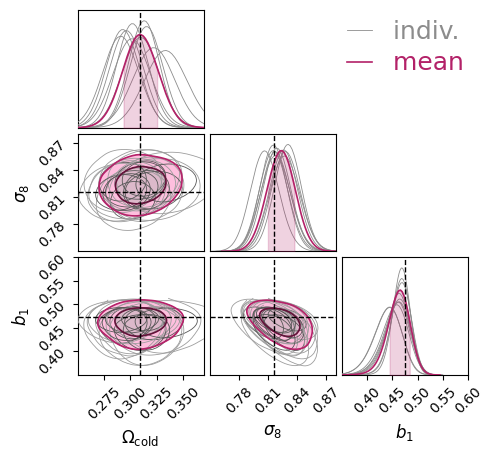

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/figA1_mean_vs_indiv_contours.png


<Figure size 640x480 with 0 Axes>

In [31]:
# Full stat combo: mean-of-stats posterior + n_plot individual realization posteriors
statistics_row = ["pk", "bispec", "pgm"]
tag_masks_row = "_kb0.25_kpgm0.25"
n_plot = 10  # number of random individual posteriors to overplot
color_indiv = "#8C8C8C"  # grey, unfilled, thin
lw_indiv, lw_mean = 0.6, 1.2
extents_a = {
    "omega_cold": [0.25, 0.37],
    "sigma8_cold": [0.75, 0.88],
    "b1": [0.35, 0.60],
}
rng_appendix_a = np.random.default_rng(0)

tags_inf, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN, tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=[statistics_row], bx=bx, tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam, n_train=n_train, tags_mask=[tag_masks_row],
)
tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
tag_stats = f'_{"_".join(statistics_row)}'
tag_test_mean = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
    tags_mask_test=[tag_masks_row],
)[0]
tag_test_sample = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test="",
    tags_mask_test=[tag_masks_row],
)[0]

fn_sample = sample_fn(tag_inf, tag_test_sample)
if not fn_sample.exists():
    raise FileNotFoundError(f"Missing sample posteriors: {fn_sample}")
print(f"fn_samples = {fn_sample}")

samples_arr = np.load(fn_sample)  # (n_draw, n_obs, n_par)
if samples_arr.ndim != 3:
    raise ValueError(f"expected 3D samples (n_draw, n_obs, n_par), got {samples_arr.shape}")
param_names_samples = np.loadtxt(
    dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str,
)
n_obs = samples_arr.shape[1]
finite_obs = np.flatnonzero(np.any(np.isfinite(samples_arr), axis=(0, 2)))
if finite_obs.size == 0:
    raise RuntimeError(f"no finite realization posteriors in {fn_sample}")

n_use = min(int(n_plot), finite_obs.size)
idxs_obs = rng_appendix_a.choice(finite_obs, size=n_use, replace=False)
print(f"overplotting {n_use}/{n_obs} individual posteriors (idxs={np.sort(idxs_obs).tolist()})")

# Individuals first (behind), mean last (on top)
samples_list = [
    (samples_arr[:, i, :], param_names_samples) for i in idxs_obs
] + [None]
tags_test = [None] * n_use + [tag_test_mean]
tags_inf_plot = [tag_inf] * (n_use + 1)
colors = [color_indiv] * n_use + [COLORS_FID[3]]
labels = ["indiv."] + [f"indiv. {j}" for j in range(1, n_use)] + ["mean"]
shades = [False] * n_use + [True]
show_labels = [True] + [False] * (n_use - 1) + [True]
linewidths = [lw_indiv] * n_use + [lw_mean]

_, _, _, _, _, _, theta_show, _ = setup_fixed_mean_test()

plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_show,
    inf_methods=["sbi"] * (n_use + 1),
    tags_inf=tags_inf_plot,
    tags_test=tags_test,
    colors=colors,
    labels=labels,
    shades=shades,
    show_label_in_legend=show_labels,
    linewidths=linewidths,
    title=None,
    extents=extents_a,
    figsize=FIGSIZE_CORNER,
    unreparameterize=True,
    samples_list=samples_list,
)
save_current_figure("figA1_mean_vs_indiv_contours")


### Appendix A2. Per-realization posterior means & widths vs SBI-on-mean

Two-row Fig.~4-style histograms: top = per-realization posterior means (relative to truth); bottom = per-realization posterior widths. Grey solid = single realizations; grey dashed = mean of inference on each realization; fiducial color = inference on the mean of 1000 statistics.


fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
fn_samples (mean)  = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
n_obs = 1000
  omega_cold:  bar(hat)-true=+0.0003043,  meanstat-true=+0.0008502,  mean σ_i=0.01447,  σ_meanstat=0.01463
  sigma8_cold:  bar(hat)-true=+0.00887,  meanstat-true=+0.007463,  mean σ_i=0.0121,  σ_meanstat=0.01215
  b1:  bar(hat)-true=-0.01487,  meanstat-true=-0.01253,  mean σ_i=0.01882,  σ_meanstat=0.0186

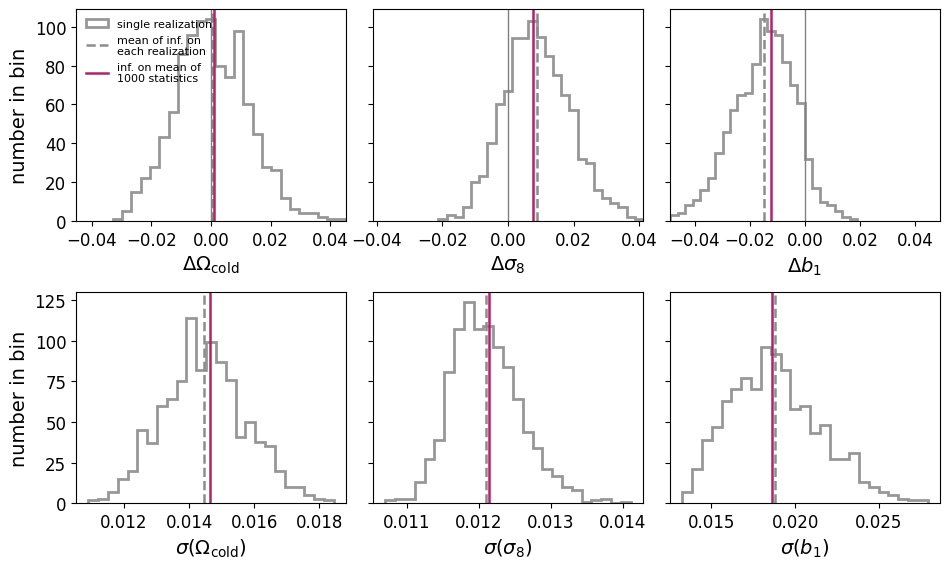

In [38]:
# Diagnostic: per-realization posterior means & widths vs SBI-on-mean (Pgg+B+Pgm)
import utils_inference

statistics_row = ["pk", "bispec", "pgm"]
tag_masks_row = "_kb0.25_kpgm0.25"
n_bins_a2 = 25  # match Fig 4
labelsize_a2 = 14
lw_hist = 2.0

tags_inf, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN, tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=[statistics_row], bx=bx, tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam, n_train=n_train, tags_mask=[tag_masks_row],
)
tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
tag_stats = f'_{"_".join(statistics_row)}'
tag_test_mean = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
    tags_mask_test=[tag_masks_row],
)[0]
tag_test_sample = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test="",
    tags_mask_test=[tag_masks_row],
)[0]

fn_sample = sample_fn(tag_inf, tag_test_sample)
fn_mean = sample_fn(tag_inf, tag_test_mean)
for fn in (fn_sample, fn_mean):
    if not fn.exists():
        raise FileNotFoundError(fn)
print(f"fn_samples (indiv) = {fn_sample}")
print(f"fn_samples (mean)  = {fn_mean}")

samples_arr = np.load(fn_sample)  # (n_draw, n_obs, n_par)
samples_mean = np.load(fn_mean)
param_names_samples = np.loadtxt(dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str)
if samples_mean.ndim == 3:
    samples_mean = samples_mean[:, 0, :]

samples_u, names_u = utils_inference.unreparameterize_theta(
    samples_arr, list(param_names_samples), strict=False,
)
names_u = list(names_u)
i_zoom = [names_u.index(pn) for pn in PARAM_NAMES_ZOOM]
theta_hat = np.nanmean(samples_u[:, :, i_zoom], axis=0)  # (n_obs, n_zoom)
sigma_hat_i = np.nanstd(samples_u[:, :, i_zoom], axis=0)  # per-realization posterior widths

samples_mean_u, names_mean_u = utils_inference.unreparameterize_theta(
    samples_mean, list(param_names_samples), strict=False,
)
names_mean_u = list(names_mean_u)
i_zoom_m = [names_mean_u.index(pn) for pn in PARAM_NAMES_ZOOM]
theta_mean_stat = np.nanmean(samples_mean_u[:, i_zoom_m], axis=0)
sigma_mean_stat = np.nanstd(samples_mean_u[:, i_zoom_m], axis=0)

_, _, _, _, _, _, theta_true, _ = setup_fixed_mean_test()
theta_true = np.asarray(theta_true, dtype=float)

n_obs = theta_hat.shape[0]
delta_hat = theta_hat - theta_true[None, :]
delta_hat_bar = np.nanmean(delta_hat, axis=0)
delta_mean_stat = theta_mean_stat - theta_true
sigma_hat_bar = np.nanmean(sigma_hat_i, axis=0)  # mean of single-realization widths

print(f"n_obs = {n_obs}")
for j, pn in enumerate(PARAM_NAMES_ZOOM):
    print(
        f"  {pn}:  "
        f"bar(hat)-true={delta_hat_bar[j]:+.4g},  "
        f"meanstat-true={delta_mean_stat[j]:+.4g},  "
        f"mean σ_i={sigma_hat_bar[j]:.4g},  "
        f"σ_meanstat={sigma_mean_stat[j]:.4g}"
    )

labels_tex = [utils_plot.param_label_dict.get(pn, pn) for pn in PARAM_NAMES_ZOOM]
color_single = "#8C8C8C"
color_mean1000 = COLORS_FID[3]
label_single = "single realization"
label_mean_singles = "mean of inf. on\neach realization"
label_mean1000 = "inf. on mean of\n1000 statistics"
n_par = len(PARAM_NAMES_ZOOM)

fig, axes = plt.subplots(2, n_par, figsize=(3.2 * n_par, 5.8), sharey="row")

for j in range(n_par):
    ax_m = axes[0, j]
    ax_s = axes[1, j]
    lab_inner = labels_tex[j].strip("$")
    show_leg = (j == 0)  # one legend on top-left panel

    # Row 0: posterior means relative to truth
    ax_m.hist(
        delta_hat[:, j], bins=n_bins_a2, histtype="step",
        color=color_single, lw=lw_hist, alpha=0.9,
        label=label_single if show_leg else None,
    )
    ax_m.axvline(
        delta_hat_bar[j], color=color_single, lw=1.8, ls="--",
        label=label_mean_singles if show_leg else None,
    )
    ax_m.axvline(
        delta_mean_stat[j], color=color_mean1000, lw=1.8,
        label=label_mean1000 if show_leg else None,
    )
    ax_m.axvline(0.0, color="grey", lw=1.0)
    ax_m.set_xlabel(rf"$\Delta${labels_tex[j]}", fontsize=labelsize_a2)
    ax_m.tick_params(labelsize=12)
    # Symmetric x-limits around truth (0)
    xmax = np.nanmax(np.abs(delta_hat[:, j]))
    ax_m.set_xlim(-xmax, xmax)

    # Row 1: posterior widths
    ax_s.hist(
        sigma_hat_i[:, j], bins=n_bins_a2, histtype="step",
        color=color_single, lw=lw_hist, alpha=0.9,
    )
    ax_s.axvline(sigma_hat_bar[j], color=color_single, lw=1.8, ls="--")
    ax_s.axvline(sigma_mean_stat[j], color=color_mean1000, lw=1.8)
    ax_s.set_xlabel(rf"$\sigma({lab_inner})$", fontsize=labelsize_a2)
    ax_s.tick_params(labelsize=12)

axes[0, 0].set_ylabel("number in bin", fontsize=labelsize_a2)
axes[1, 0].set_ylabel("number in bin", fontsize=labelsize_a2)
axes[0, 0].legend(fontsize=8, loc="upper left", frameon=False)

fig.tight_layout()
save_current_figure("figA2_posterior_means_and_widths_vs_meanstat")
plt.show()


## Appendix B. Impact of noise

Compare noiseless vs noisy training on the fixed-cosmo mean test ($P_{gg}+B+P_{gm}$).


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


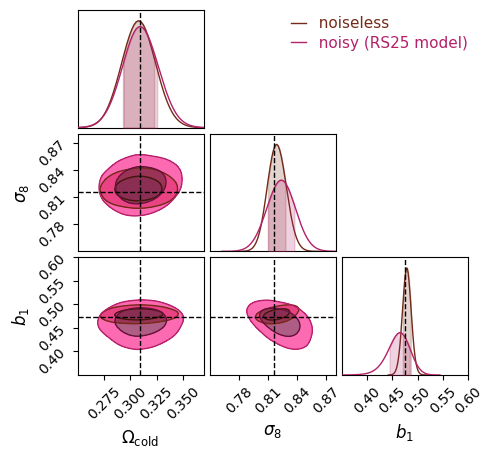

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/figB1_noise_impact_contours.png


<Figure size 640x480 with 0 Axes>

In [43]:
statistics_full = [["pk", "bispec", "pgm"]]
tag_mask_full = "_kb0.25_kpgm0.25"
tags_inf_noiseless, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams="_biasnest_p4_n320000", statistics_arr=statistics_full,
    bx=bx, tag_noise=None, tag_reparam=tag_reparam, n_train=n_train, tags_mask=[tag_mask_full],
)
tags_inf_noisy, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN, statistics_arr=statistics_full,
    bx=bx, tag_noise=TAG_NOISE_TRAIN, tag_reparam=tag_reparam, n_train=n_train, tags_mask=[tag_mask_full],
)
tags_inf_noiseless = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_noiseless]
tags_inf_noisy = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_noisy]

# Shame fixed-cosmo mean: noiseless and noisy each have their own test bias/noise tags.
tag_test_noiseless = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test="_biasshame_p0_n1", tag_stats_arr=["_pk_bispec_pgm"],
    tag_noise_test=None, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
    tags_mask_test=[tag_mask_full],
)[0]
tag_test_noisy = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=["_pk_bispec_pgm"],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
    tags_mask_test=[tag_mask_full],
)[0]

fn_noiseless = sample_fn(tags_inf_noiseless[0], tag_test_noiseless)
fn_noisy = sample_fn(tags_inf_noisy[0], tag_test_noisy)
appendix_b_files = [
    ("noiseless train × shame mean", fn_noiseless),
    ("noisy train × shame mean", fn_noisy),
]
missing = [(label, fn) for label, fn in appendix_b_files if not fn.exists()]
existing = [(label, fn) for label, fn in appendix_b_files if fn.exists()]
if missing:
    print("ERROR: Appendix B needs one noiseless and one noisy shame-mean sample file.")
    print("Missing:")
    for label, fn in missing:
        print(f"  - {label}: {fn}")
    if existing:
        print("Found:")
        for label, fn in existing:
            print(f"  - {label}: {fn}")
else:
    _, _, _, _, _, _, theta_show, _ = setup_fixed_mean_test()

    extents_b = {
        "omega_cold": [0.25, 0.37],
        "sigma8_cold": [0.75, 0.88],
        "b1": [0.35, 0.60],
    }
    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_show,
        inf_methods=["sbi", "sbi"], tags_inf=[tags_inf_noiseless[0], tags_inf_noisy[0]],
        tags_test=[tag_test_noiseless, tag_test_noisy],
        colors=["#742a18", COLORS_FID[3]],
        labels=["noiseless", "noisy (RS25 model)"],
        shades=[True, True],
        title=None,
        extents=extents_b,
        figsize=FIGSIZE_CORNER, unreparameterize=True,
        fontsize_legend=11,
    )
    save_current_figure("figB1_noise_impact_contours")


## Appendix C. Full posteriors (cosmic variance & SHAMe)

All varied parameters including $A_\mathrm{noise}$ parameters. Fiducial stat combos on fixed-cosmo mean and SHAMe.

In [ ]:
def plot_all_params(
    tags_inf, labels, colors, tags_test, keep, theta_obs, param_vary, *,
    truth_exclude=None, truth_color="k", save_name=None,
):
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print("No samples for full-posterior plot")
        return
    extents_all = {
        **genp.get_bounds("cosmo"), **genp.get_bounds("bias"),
        **genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION),
    }
    extents_all["b1"] = extents_contours["b1"]
    theta_vec = np.asarray(theta_obs, dtype=float).reshape(-1)
    truth_kwargs = {}
    if truth_exclude:
        exclude = set(truth_exclude)
        truth_loc = {
            pn: float(theta_vec[param_vary.index(pn)])
            for pn in param_vary
            if pn not in exclude and np.isfinite(theta_vec[param_vary.index(pn)])
        }
        truth_kwargs = dict(add_truth=True, truth_locations=[truth_loc], theta_obs_true=None)
    else:
        truth_kwargs = dict(add_truth=True, theta_obs_true=theta_vec)
    plotter.plot_contours_inf(
        param_names=list(param_vary), idx_obs=idx_obs,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs], tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs], labels=[labels[i] for i in idxs],
        title=None, extents=extents_all, figsize=FIGSIZE_ALL_PARAMS,
        fontsize_legend=10, loc_legend=(1.02, 0.98), unreparameterize=True,
        **truth_kwargs,
    )
    if save_name is not None:
        save_current_figure(save_name)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2

Parameter b2 in chain $P_\mathrm{gg}(k)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ is not constrained
Parameter An_b1 in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ is not constrained


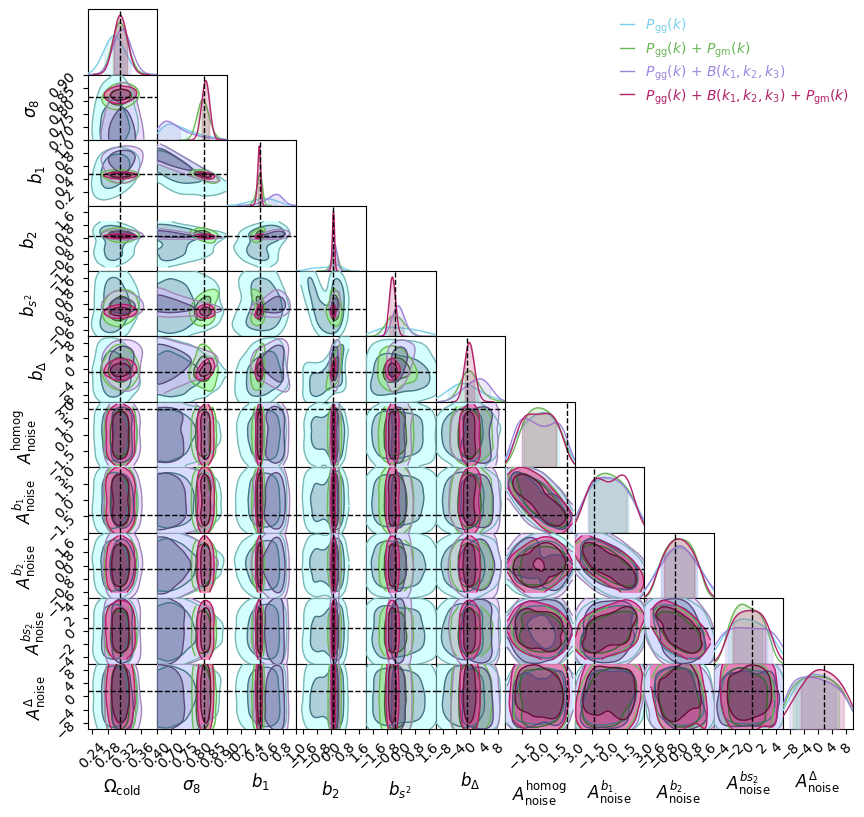

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/figC1_cosmic_variance_full_posteriors.png


<Figure size 640x480 with 0 Axes>

In [ ]:
tags_inf, labels, colors, tags_test, keep, theta_obs_full, _, param_vary = setup_fixed_mean_test()
plot_all_params(
    tags_inf, labels, colors, tags_test, keep,
    theta_obs_full, param_vary,
    save_name="figC1_cosmic_variance_full_posteriors",
)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022_pred.npy


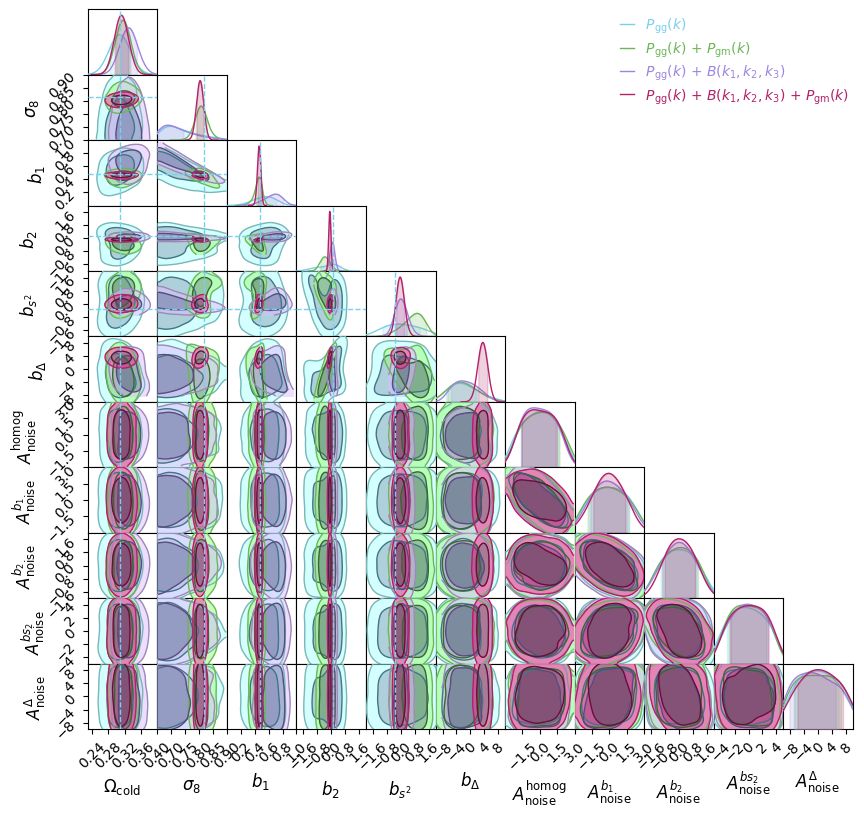

Saved: /home/kstoreyf/muchisimocks/figures/2026-06-25_paper_figures/figC2_shame_full_posteriors.png


<Figure size 640x480 with 0 Axes>

In [ ]:
tags_inf, labels, colors, tags_test, keep, param_vary, _ = setup_shame_test()
theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME)
theta_shame_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
plot_all_params(
    tags_inf, labels, colors, tags_test, keep,
    theta_shame_full, param_vary,
    truth_exclude=["bl"],
    save_name="figC2_shame_full_posteriors",
)
